# Time series forecast from scratch

## 1. What is a Time Series?

A time series(TS) is a collection of data points collected at constant time intervals. These are analyzed to determine the long-term trend, enabling the forecasting of future events or facilitating other forms of analysis. But what makes a TS different from, say, a regular regression problem? There are two things:

1.  It is time-dependent. So, the basic assumption of a linear regression model —that the observations are independent —doesn’t hold in this case.
2.  Along with an increasing or decreasing trend, most TS have some form of seasonality trends, i.e., variations specific to a particular time frame. For example, if you see the sales of a woolen jacket over time, you will invariably find higher sales in winter seasons.


## 2. Loading and Handling Time Series in Pandas

Pandas has dedicated libraries for handling TS objects, particularly the datetime64[ns] class, which stores time information and allows us to perform some operations really fast. In this example, we will use the International airline passengers dataset.

In [15]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'
rcParams["legend.loc"] = 'upper left'

In [16]:
dateparse = lambda dates: pd.to_datetime(dates, format="%Y-%m")
data = pd.read_csv(
    "https://raw.githubusercontent.com/GVSU-CIS635/Datasets/master/airline-passengers.csv",
    parse_dates=["Month"],
    index_col="Month",
    date_parser=dateparse,
)

data.head()

/tmp/ipython-input-2228116854.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = pd.read_csv(


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


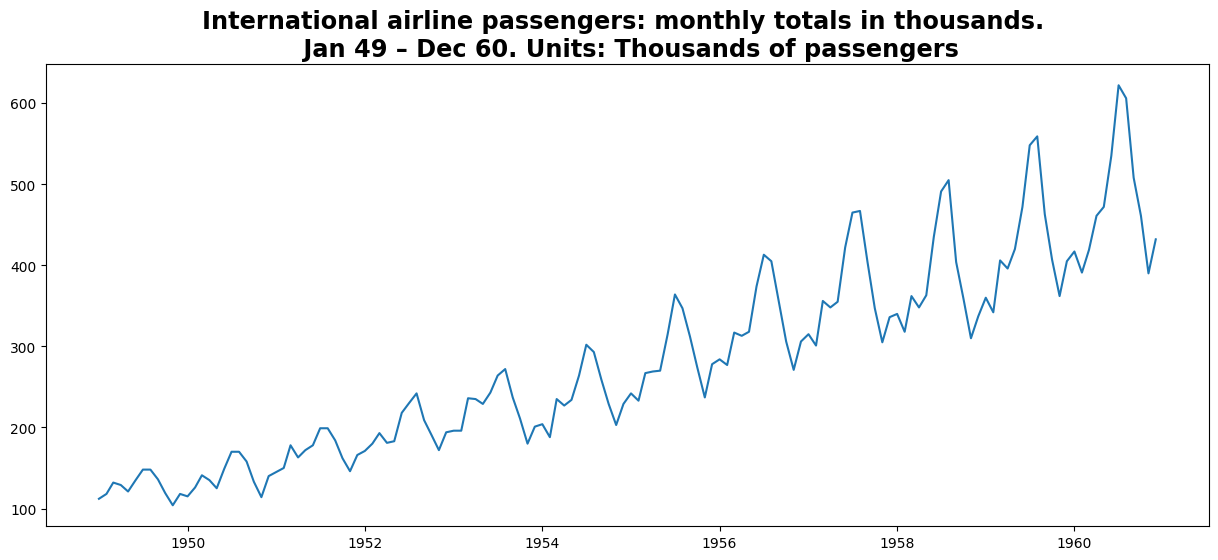

In [17]:
passengers = data["Passengers"]
plt.title(
    "International airline passengers: monthly totals in thousands. \n Jan 49 – Dec 60. Units: Thousands of passengers"
)
plt.plot(passengers)
# print (type(ts))

### Split Dataset

We can split the dataset into two parts.

The first part is the training dataset that we will use to train our model. The second part is the test dataset, which we will assume is unavailable. It is these time steps that we will treat as out of sample.

The dataset contains data from January 1949 to December 1960.

We will reserve the last 2 years of the dataset as the test dataset, treating those time steps as out-of-sample data.


In [18]:
split_validation = len(data) - 36
split_test = len(data) - 24
ts, ts_val, ts_test = (
    passengers[0:split_validation],
    passengers[split_validation:split_test],
    passengers[split_test:],
)
print("Training %d, Validation %d, Test %d" % (len(ts), len(ts_val), len(ts_test)))
print(type(ts))

Training 108, Validation 12, Test 24
<class 'pandas.core.series.Series'>


## 3.Stationarity of a Time Series

A TS is said to be stationary if its statistical properties, such as mean and variance, remain constant over time. But why is it important? Most of the TS models work on the assumption that the TS is stationary. Intuitively, we can say that if a TS exhibits a particular behavior over time, there is a very high probability that it will continue to do so in the future. Also, the theories related to stationary series are more mature and easier to implement as compared to non-stationary series.

Stationarity is defined using a stringent criterion. However, for practical purposes, we can assume the series to be stationary if it has constant statistical properties over time, ie, the following:

<img src="https://qph.cf2.quoracdn.net/main-qimg-0a74900b87e1b71a02fedaa3bc4d6839-pjlq" width="500">


Checking stationarity, we’ll be using the rolling statistics plots along with Dickey-Fuller test results. Refer [this article](https://www.analyticsvidhya.com/blog/2015/12/complete-tutorial-time-series-modeling/) for details.


In [19]:
from statsmodels.tsa.stattools import adfuller


def test_stationarity(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(window=12, center=False).mean()
    rolstd = timeseries.rolling(window=12, center=False).std()

    # Plot rolling statistics:
    orig = plt.plot(timeseries, color="blue", label="Original")
    mean = plt.plot(rolmean, color="red", label="Rolling Mean")
    std = plt.plot(rolstd, color="black", label="Rolling Std")
    plt.legend(loc="best")
    plt.title("Rolling Mean & Standard Deviation")
    plt.show(block=False)

    # Perform Dickey-Fuller test:
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

    if dftest[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

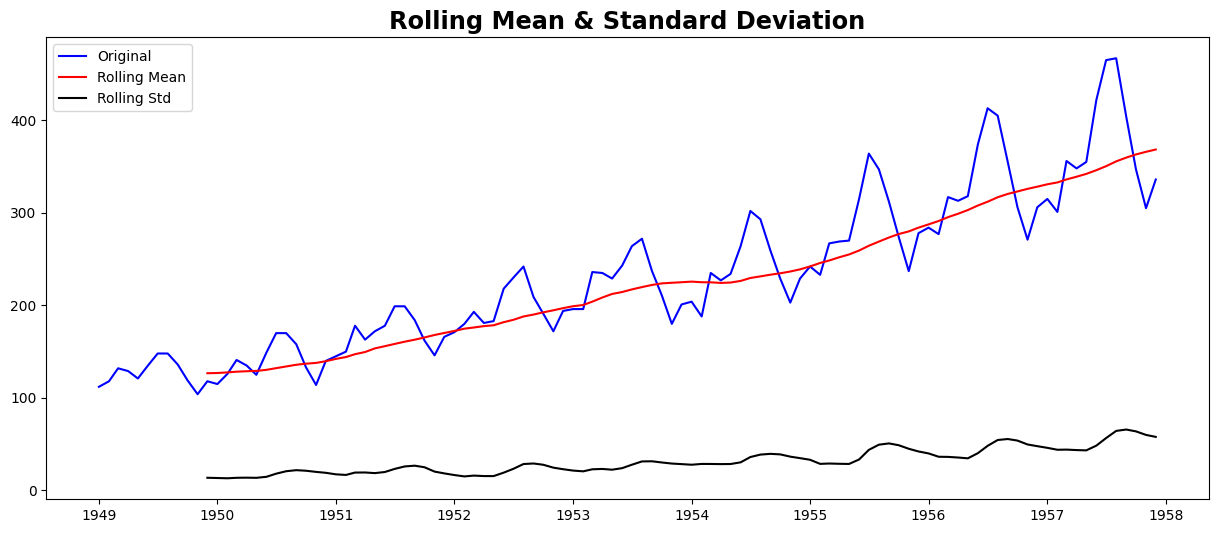

Results of Dickey-Fuller Test:
Test Statistic                  1.002587
p-value                         0.994293
#Lags Used                     13.000000
Number of Observations Used    94.000000
Critical Value (1%)            -3.501912
Critical Value (5%)            -2.892815
Critical Value (10%)           -2.583454
dtype: float64
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [20]:
test_stationarity(ts)

Though the variation in standard deviation is small, the mean is clearly increasing with time, and this is not a stationary series. Also, the test statistic is way more than the critical values. Note that the signed values should be compared and not the absolute values.


## 4. Making a Time Series Stationary

In practice, time series are not usually stationary. There are methods statisticians can use to get time series closer to stationarity.

Let's review what makes a TS non-stationary

1.  **Trend** - variation in the mean over time. In this example, the mean increases.
2.  **Seasonality** - cyclic variations. In this case, the seasonality exists in a spiked disturbance that resembles a sawtooth waveform.

The goal in forecasting a time series is to remove the components of trend and seasonality so that the remaining series (the residuals) becomes stationary. The stationary residuals are then modeled to forecast future values of the time series.


### Estimating & Eliminating Trend

One of the first tricks to reduce trend can be transformation. For example, in this case, we can clearly see that there is a significant positive trend. So we can apply a transformation that penalizes higher values more than smaller values. These can be taking a log, square root, cube root, etc. Let's take a log transform here for simplicity:


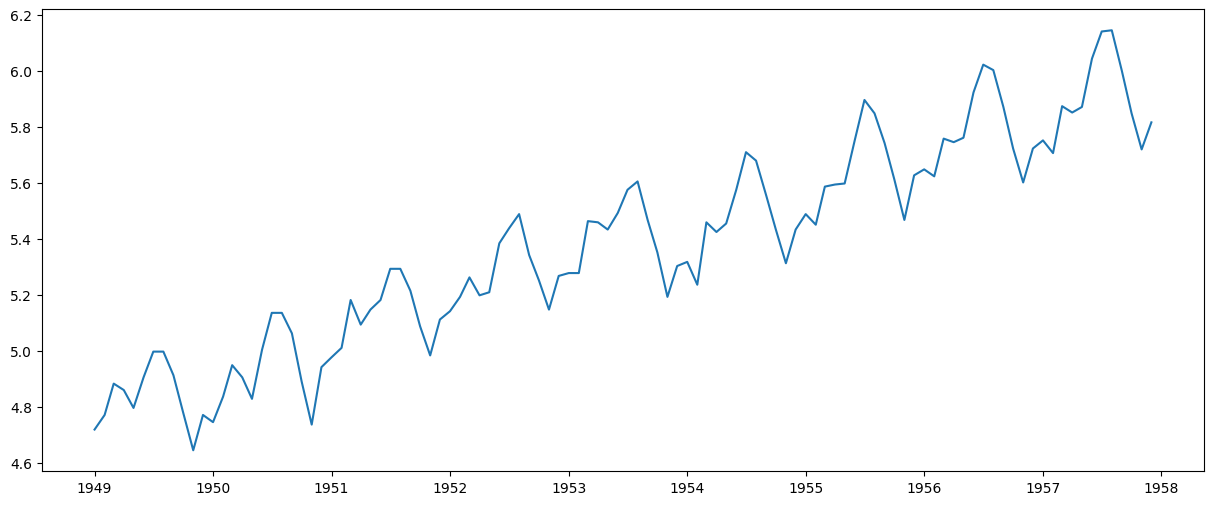

In [21]:
ts_log = np.log(ts)
plt.plot(ts_log)

In this simpler case, it is easy to see a forward trend in the data. But it's not very intuitive in the presence of noise. So we can use some techniques to estimate or model this trend and then remove it from the series.


### Moving average

In this approach, we take the average of ‘k’ consecutive values depending on the frequency of the time series. Here we can take the average over the past 1 year, i.e. last 12 values. Pandas has specific functions defined for determining rolling statistics.

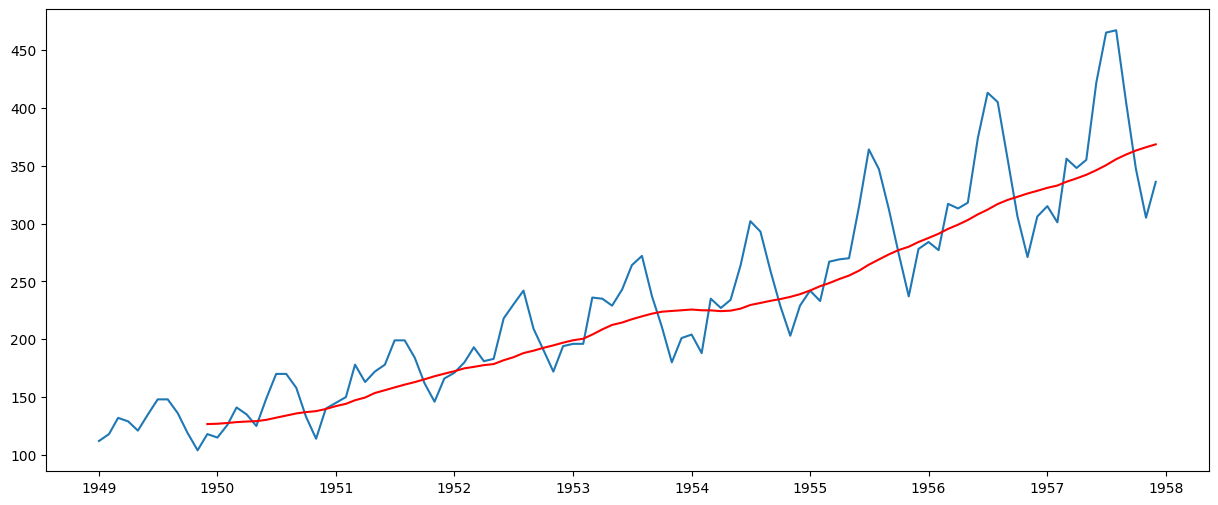

In [22]:
moving_avg = ts.rolling(window=12, center=False).mean()
plt.plot(ts)
plt.plot(moving_avg, color="red")

The red line shows the rolling mean. Let's subtract this from the original series. Note that since we are taking the average of the last 12 values, the rolling mean is not defined for the first 11 values. This can be observed as:

In [23]:
ts_moving_avg_diff = ts - moving_avg
ts_moving_avg_diff.head(12)

,Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


Notice the first 11 being Nan. Let's drop these NaN values and check the plots to test stationarity.


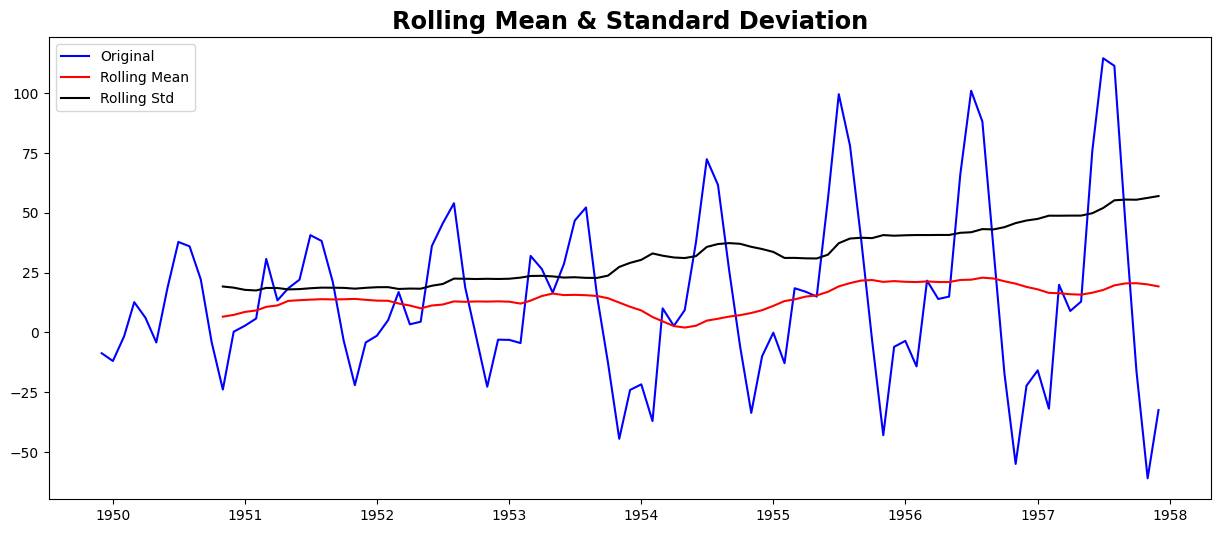

Results of Dickey-Fuller Test:
Test Statistic                 -1.782340
p-value                         0.389264
#Lags Used                     12.000000
Number of Observations Used    84.000000
Critical Value (1%)            -3.510712
Critical Value (5%)            -2.896616
Critical Value (10%)           -2.585482
dtype: float64
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [24]:
ts_moving_avg_diff.dropna(inplace=True)
test_stationarity(ts_moving_avg_diff)

This looks like a much better series. The rolling values appear to be varying slightly, but there is no specific trend. But the test statistic is still greater than the critical values. A drawback of this approach is that the time period must be strictly defined. In this case, we can take yearly averages, but in complex situations like forecasting a stock price, it's challenging to come up with a number. So we take a ‘weighted moving average’ where more recent values are given a higher weight. There can be many techniques for assigning weights. A popular one is the **exponentially weighted moving average**, where weights are assigned to all the previous values with a decay factor. Find details here. This can be implemented in Pandas as:


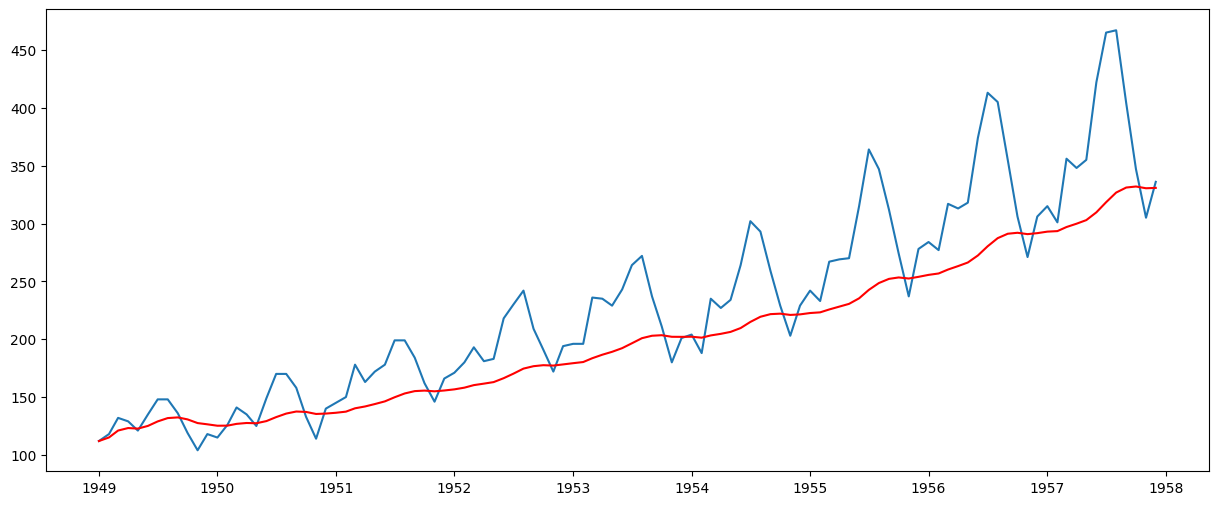

In [25]:
expwighted_avg = ts.ewm(halflife=12, min_periods=0, adjust=True, ignore_na=False).mean()
plt.plot(ts)
plt.plot(expwighted_avg, color="red")

Note that here the parameter ‘halflife’ is used to define the amount of exponential decay. This is just an assumption here and would depend mainly on the business domain. Other parameters, such as span and center of mass, can also be used to define decay; these are discussed in the link shared above. Now, let’s remove this from the series and check stationarity:


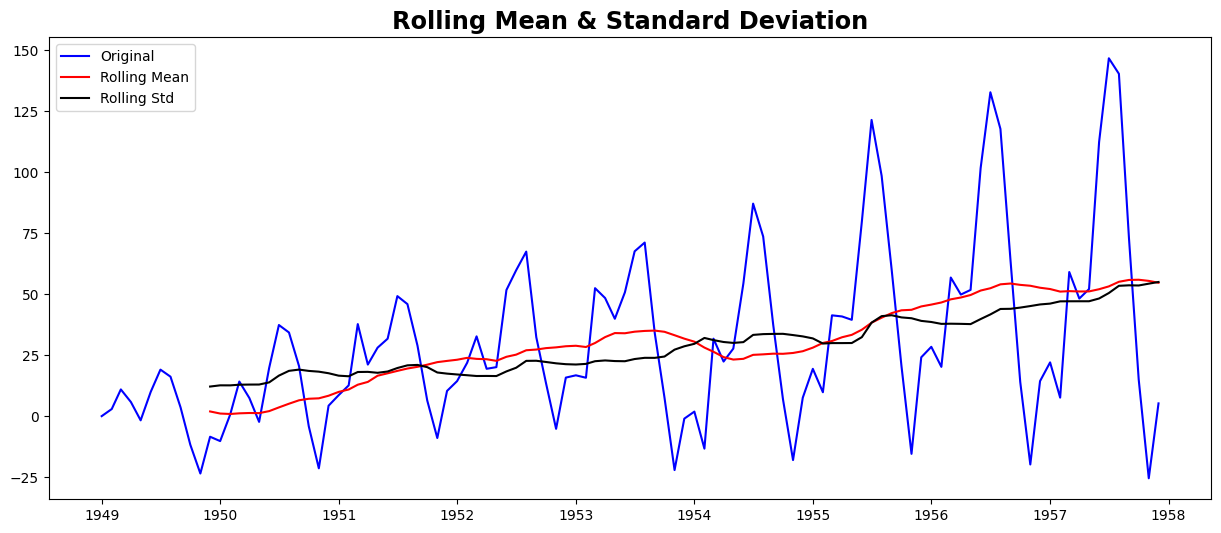

Results of Dickey-Fuller Test:
Test Statistic                 -1.550487
p-value                         0.508405
#Lags Used                     13.000000
Number of Observations Used    94.000000
Critical Value (1%)            -3.501912
Critical Value (5%)            -2.892815
Critical Value (10%)           -2.583454
dtype: float64
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [26]:
ts_ewma_diff = ts - expwighted_avg
test_stationarity(ts_ewma_diff)

However, the test statistic is still non-stationary. Note that in this case, there will be no missing values as all values from the start are given weights. So it’ll work even with no previous values.


### Differencing

The simple trend reduction techniques discussed previously are not effective in all cases, particularly those with high seasonality. One of the most common methods of dealing with both trend and seasonality is differencing. In this technique, we calculate the difference between the observation at a particular instant and that at the previous instant. This primarily works well in improving stationarity. First-order differencing can be done in Pandas as:


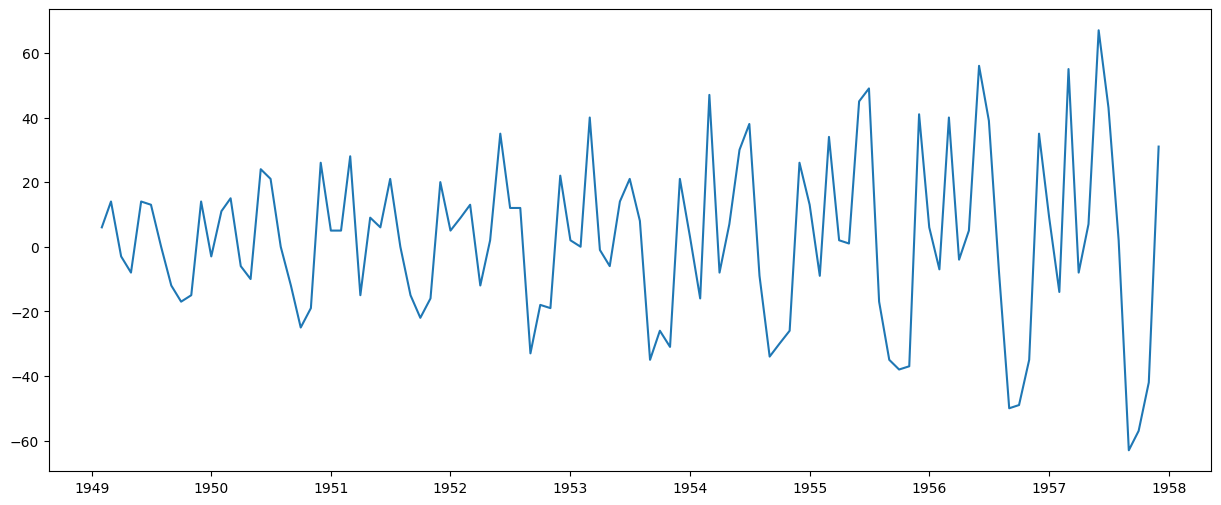

In [27]:
ts_diff = ts - ts.shift()
plt.plot(ts_diff)

This appears to have reduced the trend considerably. Let's verify:


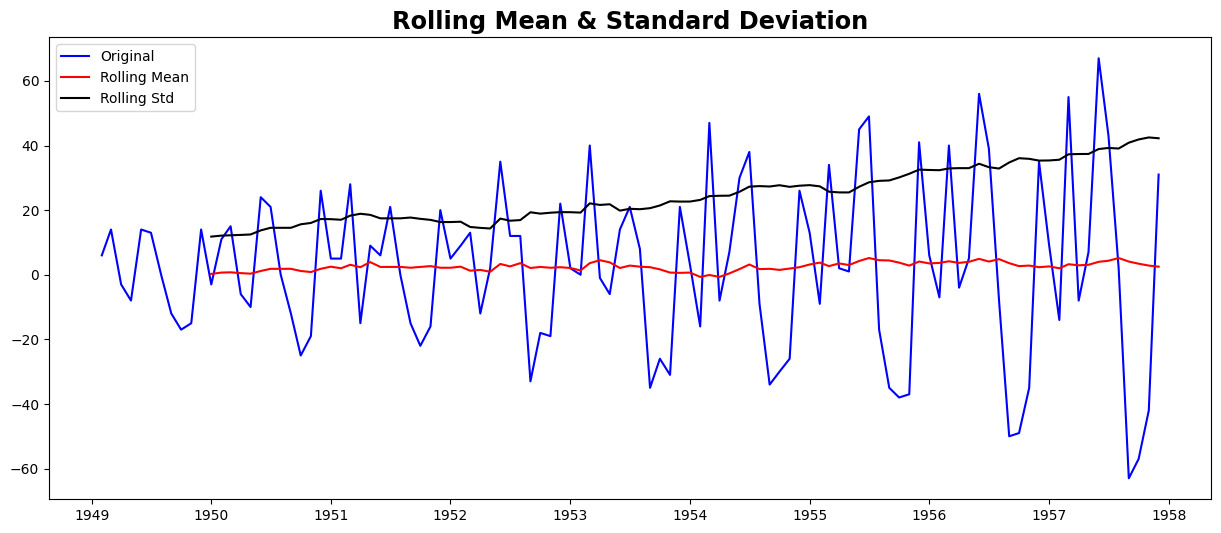

Results of Dickey-Fuller Test:
Test Statistic                 -2.282546
p-value                         0.177659
#Lags Used                     12.000000
Number of Observations Used    94.000000
Critical Value (1%)            -3.501912
Critical Value (5%)            -2.892815
Critical Value (10%)           -2.583454
dtype: float64
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [28]:
ts_diff.dropna(inplace=True)
test_stationarity(ts_diff)

We can see that the mean and std deviation have slight variations with time. Also, the Dickey-Fuller test statistic is still greater than the critical values. We can also consider second or third order differences, which may yield even better results in specific applications.


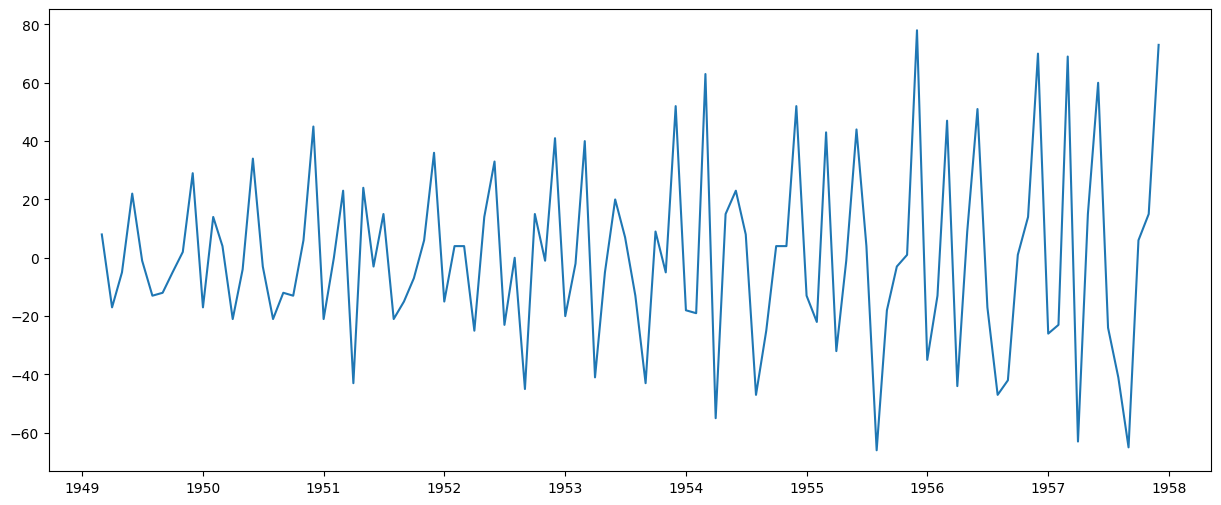

In [29]:
ts_diff2 = ts - ts.shift() - (ts.shift() - ts.shift(2))
plt.plot(ts_diff2)

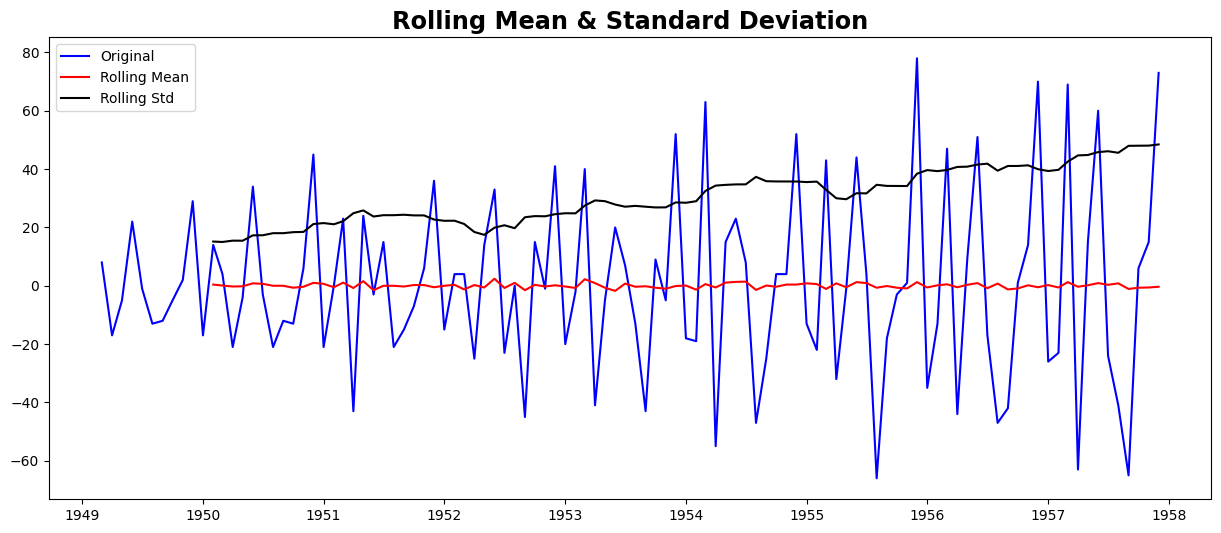

Results of Dickey-Fuller Test:
Test Statistic                -7.210240e+00
p-value                        2.244708e-10
#Lags Used                     1.300000e+01
Number of Observations Used    9.200000e+01
Critical Value (1%)           -3.503515e+00
Critical Value (5%)           -2.893508e+00
Critical Value (10%)          -2.583824e+00
dtype: float64
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [30]:
ts_diff2.dropna(inplace=True)
test_stationarity(ts_diff2)

## 5. Forecasting a Time Series

We observed various techniques, and all of them performed reasonably well in making the TS stationary. Let's make a model on the TS after differencing, as it is a very popular technique. Also, it's relatively more straightforward to add noise and seasonality back into predicted residuals in this case. Having performed the trend and seasonality estimation techniques, there can be two situations:

1.  **A strictly stationary series** with no dependence among the values. This is the easy case wherein we can model the residuals as white noise. But this is very rare.
2.  A series with significant **dependence among values**. In this case, we need to use some statistical models like ARIMA to forecast the data.

Let me give you a brief introduction to **ARIMA**. I won’t delve into the technical details, but understanding these concepts in detail is essential if you wish to apply them more effectively. ARIMA stands for **Auto-Regressive Integrated Moving Averages**. The ARIMA forecasting for a stationary time series is nothing but a linear (like a linear regression) equation. The predictors depend on the parameters (p,d,q) of the ARIMA model:

1.  **Number of AR (Auto-Regressive) terms (p)**: AR terms are just lags of the dependent variable. For instance, if p is 5, the predictors for x(t) will be x(t-1)….x(t-5).
2.  **Number of MA (Moving Average) terms (q)**: MA terms are lagged forecast errors in the prediction equation. For instance, if q is 5, the predictors for x(t) will be e(t-1)….e(t-5), where e(i) is the difference between the moving average at the ith instant and the actual value.
3.  **Number of Differences (d)**: These are the number of nonseasonal differences, i.e., in this case, we took the second-order difference. We can either pass that variable and set d=0, or pass the original variable and set d=2. Both will generate the same results.

A significant concern here is how to determine the value of ‘p’ and ‘q’. We use two plots to determine these numbers. Let's discuss them first.

1.  **Autocorrelation Function (ACF)**: It is a measure of the correlation between the TS and a lagged version of itself. For instance, at lag 5, ACF would compare series at time instant ‘t1’…’t2’ with series at instant ‘t1-5’…’t2-5’ (t1-5 and t2 being end points).
2.  **Partial Autocorrelation Function (PACF)**: This measures the correlation between the TS with a lagged version of itself, but after eliminating the variations already explained by the intervening comparisons. E.g., at lag 5, it will check the correlation but remove the effects already explained by lags 1 to 4.

The ACF and PACF plots for the TS after differencing can be plotted as:


In [31]:
# ACF and PACF plots:
from statsmodels.tsa.stattools import acf, pacf

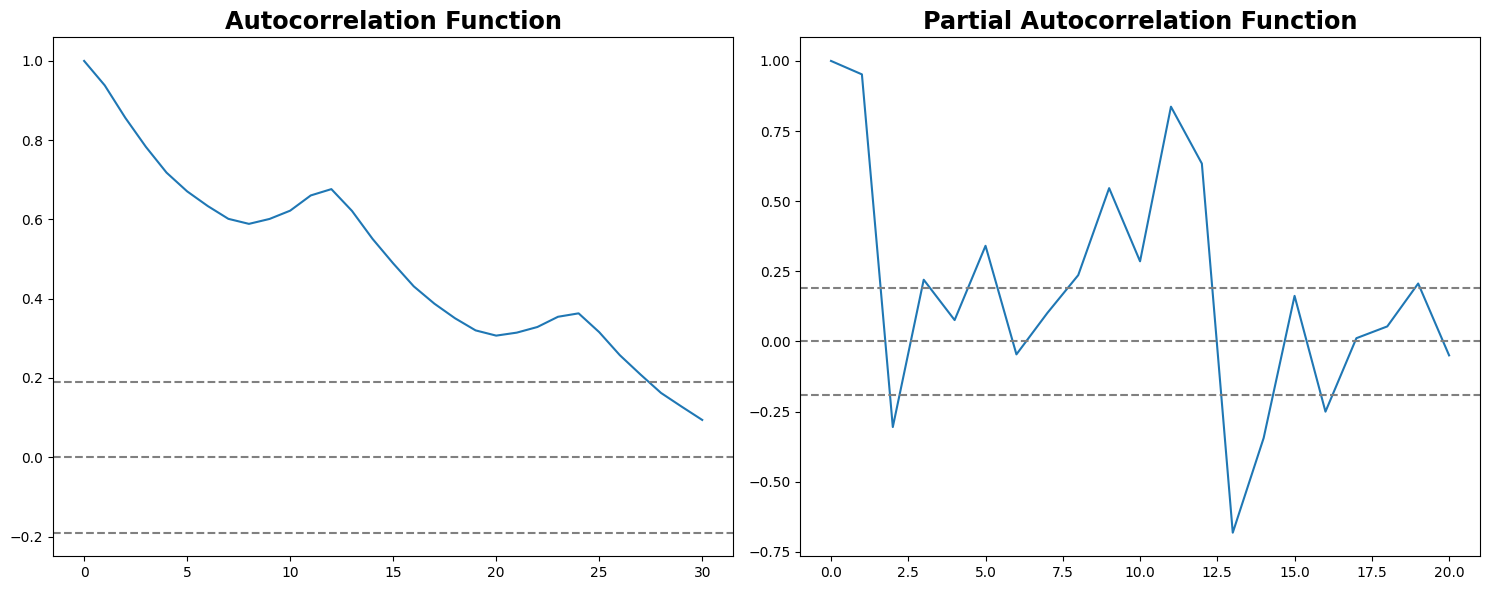

In [32]:
lag_acf = acf(ts, nlags=30)
lag_pacf = pacf(ts, nlags=20, method="ols")

# Plot ACF:
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0, linestyle="--", color="gray")
plt.axhline(y=-1.96 / np.sqrt(len(ts_diff2)), linestyle="--", color="gray")
plt.axhline(y=1.96 / np.sqrt(len(ts_diff2)), linestyle="--", color="gray")
plt.title("Autocorrelation Function")

# Plot PACF:
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0, linestyle="--", color="gray")
plt.axhline(y=-1.96 / np.sqrt(len(ts_diff2)), linestyle="--", color="gray")
plt.axhline(y=1.96 / np.sqrt(len(ts_diff2)), linestyle="--", color="gray")
plt.title("Partial Autocorrelation Function")
plt.tight_layout()

In this plot, the two dotted lines on either side of 0 are the confidence intervals. These can be used to determine the ‘p’ and ‘q’ values as:

1.  **p** – The lag value where the [**PACF**](https://en.wikipedia.org/wiki/Partial_autocorrelation_function#:~:text=In%20time%20series%20analysis%2C%20the,not%20control%20for%20other%20lags.) chart crosses the upper confidence interval for the first time. If you notice closely, in this case, p = 2.
2.  **q** – The lag value where the [**ACF**](https://en.wikipedia.org/wiki/Autocorrelation) chart crosses the upper confidence interval for the first time. In this case, q = 27.

The ACF and PACF provide a heuristic or an initial estimate. The actual 'q' value that yields the best model might be different.

Now, let's create three different ARIMA models, considering both individual and combined effects. I will also print the **residual sum of squares (RSS)** for each. Please note that here, RSS is for the values of residuals and not the actual series.

We need to load the ARIMA model first:


The p,d,q values can be specified using the order argument of ARIMA which take a tuple (p,d,q). Let model the 3 cases:

### AR Model


In [34]:
from statsmodels.tsa.arima.model import ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


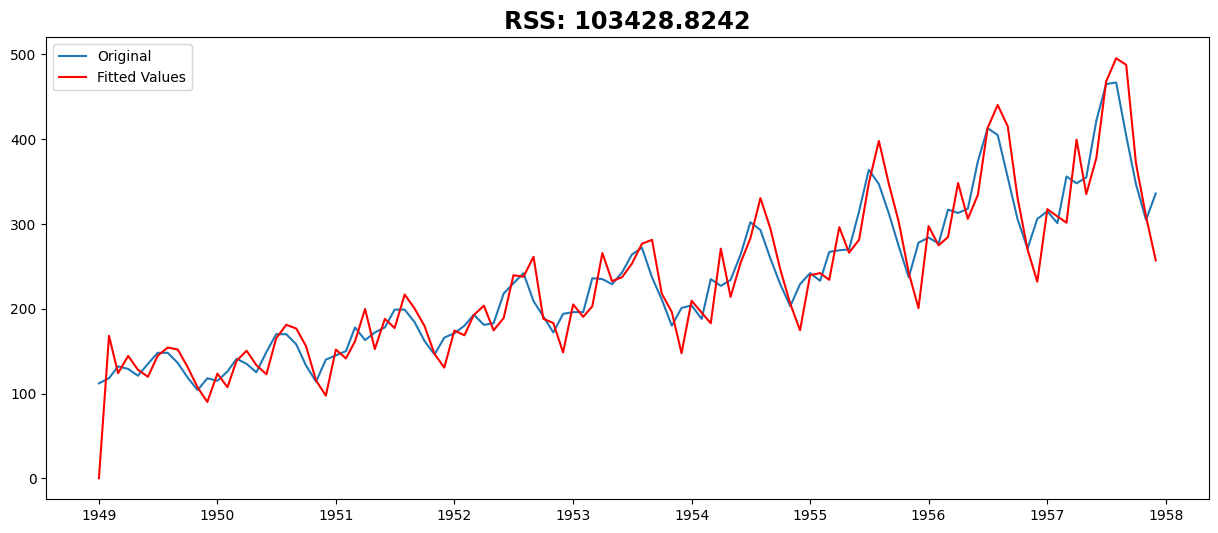

In [35]:
model = ARIMA(ts, order=(2, 2, 0))
results_AR = model.fit()
plt.plot(ts, label="Original")
plt.plot(results_AR.fittedvalues, color="red", label="Fitted Values")
plt.title("RSS: %.4f" % sum((results_AR.fittedvalues - ts) ** 2))
plt.legend(loc="best")
plt.show()

### MA Model


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

Text(0.5, 1.0, 'RSS: 31127.8509')

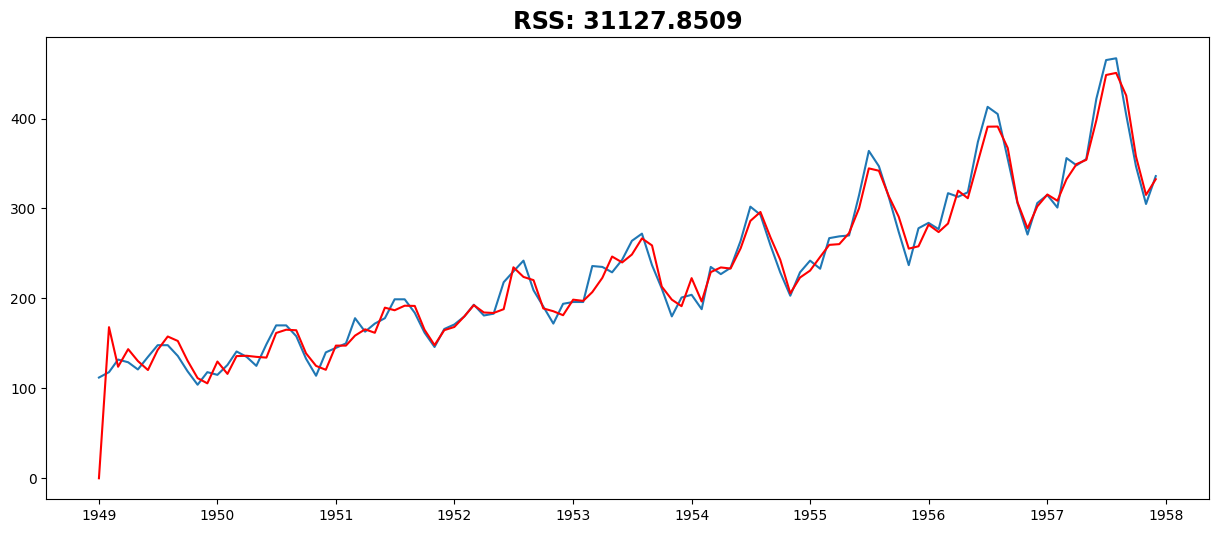

In [36]:
model = ARIMA(ts, order=(0, 2, 27))
results_MA = model.fit()
plt.plot(ts)
plt.plot(results_MA.fittedvalues, color="red")
plt.title("RSS: %.4f" % sum((results_MA.fittedvalues - ts) ** 2))

### Combined Model


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

Text(0.5, 1.0, 'RSS: 31685.6844')

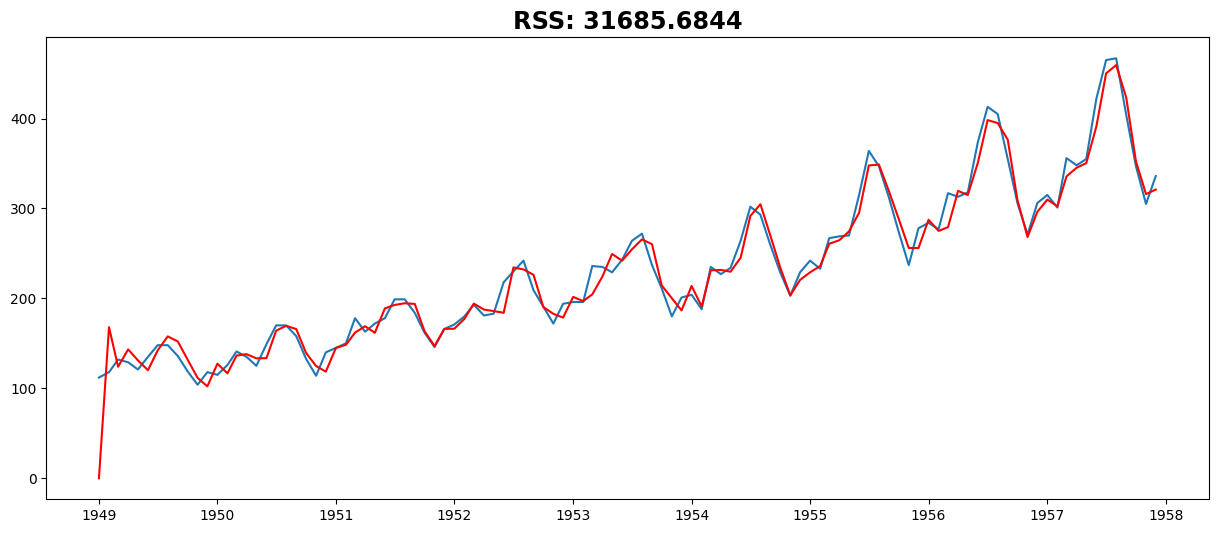

In [37]:
model = ARIMA(ts, order=(2, 2, 27))
results_ARIMA = model.fit()
plt.plot(ts)
plt.plot(results_ARIMA.fittedvalues, color="red")
plt.title("RSS: %.4f" % sum((results_ARIMA.fittedvalues - ts) ** 2))

### Multi-Step Forecasting


In [38]:
yhat_val = results_ARIMA.forecast(steps=12)
yhat_test = results_ARIMA.forecast(steps=36)[-24:]

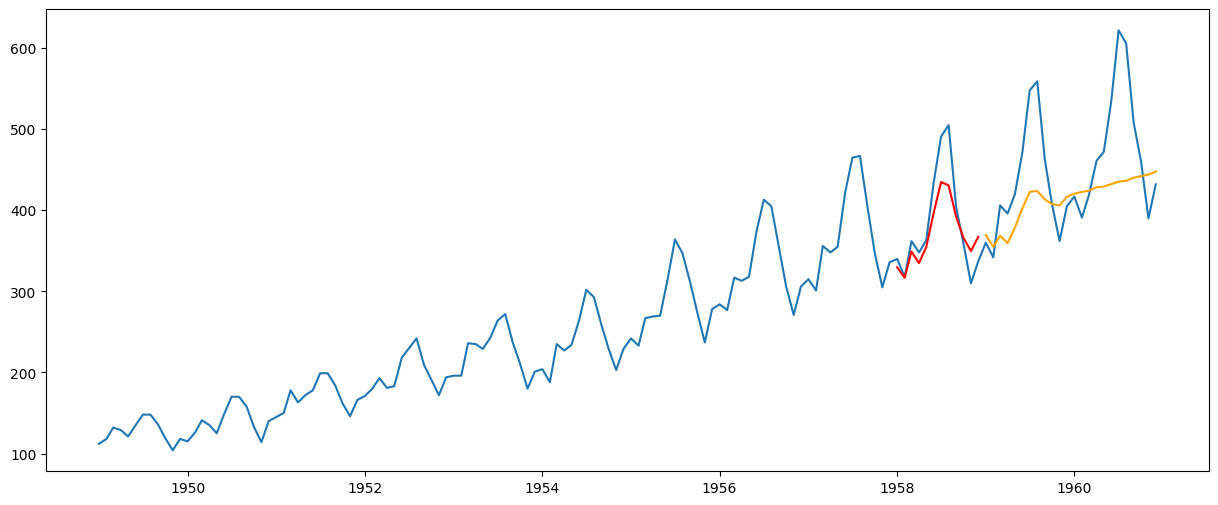

In [39]:
plt.plot(passengers)
plt.plot(yhat_val, color="red")
plt.plot(yhat_test, color="orange")

### Recursive (Iterative) Forecasting


In [ ]:
training = ts
for i in range(split_validation, len(passengers)):
    model = ARIMA(training, order=(2, 2, 27))
    results_ARIMA = model.fit()
    forecast = results_ARIMA.forecast(steps=1)
    training = pd.concat([training, forecast])
plt.plot(passengers)
plt.plot(training)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals